These distribution plots are after redundant sequences have been removed. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## CDRH3 Length Distribution

In [6]:
def get_cdrh3_lengths(search_name):
    '''
    Load in sequences, calculate cdrh3 lengths. 
    '''
    load_path=f'/Users/ssolieva/Desktop/github_repo/Q23_paper/OAS_database_searches/V033/{search_name}/data/parsed_logfile/' # path to where the search results are (logfile).  
    cdrh3_sequences_per_donor = np.load(f'{load_path}redundant_seqs_removed_within_donors_cdrh3_final.npy', allow_pickle=True) # load in the data after redudant sequences per donor have been removed. 
    cdrh3_lengths_donors_combined = [] # number of non-redundant sequences per donor. 'collapsed' = non-redundant. 
    for i in range(len(cdrh3_sequences_per_donor)): # iterate through all donors. 
        for j in range(len(cdrh3_sequences_per_donor[i])):
            cdrh3_lengths_donors_combined.append(int(len(cdrh3_sequences_per_donor[i][j]))) # save the number of sequences. 
    return cdrh3_lengths_donors_combined

In [7]:
search_name = 'search3'
cdrh3_lengths_donors_combined = get_cdrh3_lengths(search_name)
print('Number of sequences \t', len(cdrh3_lengths_donors_combined))
print('Shortest CDRH3\t\t', np.min(cdrh3_lengths_donors_combined))
print('Longest CDRH3\t\t', np.max(cdrh3_lengths_donors_combined))

Number of sequences 	 24696
Shortest CDRH3		 13
Longest CDRH3		 64


lengths = cdrh3_lengths_donors_combined

barplot_lengths = []
for i in range(20,40):
    barplot_lengths.append(lengths.count(i))
plt.figure(figsize=[4,2])
plt.bar(np.arange(20,40), barplot_lengths, width=1, edgecolor='k', color='#5596ce')
plt.xticks(np.arange(20,42,2))
plt.xlim(20,40)
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.ylabel('Number of sequences',weight='bold', fontsize=12)
plt.xlabel('CDRH3 length',weight='bold', fontsize=12)
plt.title('PG9: Search 7',weight='bold', fontsize=12)

figure_path = '/Users/ssolieva/Desktop/github_repo/q23-manuscript/repertoire-frequency-analysis/OAS-searches/figures/'
plt.savefig(f'{figure_path}SI_Fig1_PanelC__PG_nonredundant_CDRH3_length_distribution.pdf', dpi=300, transparent=True, bbox_inches='tight')
plt.savefig(f'{figure_path}SI_Fig1_PanelC__PG9_nonredundant_CDRH3_length_distribution.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

## gene distribution

In [8]:
def group_according_to_donors(updated_donor_names, updated_vgene, updated_dgene, updated_jgene, save_path):
    import numpy as np
    
    dgenes = updated_dgene
    jgenes = updated_jgene
    vgenes = updated_vgene
    
    donor_names = updated_donor_names
    unique_donor_names = np.unique(updated_donor_names)

    vgenes_by_donor = []
    dgenes_by_donor = []
    jgenes_by_donor = []
    for i in range(len(unique_donor_names)):
        tmp_vgene = []
        tmp_dgene = []
        tmp_jgene = []
        for j in range(len(donor_names)):
            tmp_tmp_vgene = []
            tmp_tmp_dgene = []
            tmp_tmp_jgene = []
            if donor_names[j] == unique_donor_names[i] and donor_names[j] != 'no' and donor_names[j] != 'no_donor_name_found':
                tmp_tmp_vgene.append(vgenes[j])
                tmp_tmp_dgene.append(dgenes[j])
                tmp_tmp_jgene.append(jgenes[j])
            tmp_vgene.append(tmp_tmp_vgene)
            tmp_dgene.append(tmp_tmp_dgene)
            tmp_jgene.append(tmp_tmp_jgene)
        vgenes_by_donor.append(np.concatenate(tmp_vgene))
        dgenes_by_donor.append(np.concatenate(tmp_dgene))
        jgenes_by_donor.append(np.concatenate(tmp_jgene))

    np.save(f'{save_path}vgenes_by_donor',np.array(vgenes_by_donor, dtype=object))
    np.save(f'{save_path}dgenes_by_donor',np.array(dgenes_by_donor, dtype=object))
    np.save(f'{save_path}jgenes_by_donor',np.array(jgenes_by_donor, dtype=object))

    return unique_donor_names, vgenes_by_donor, dgenes_by_donor, jgenes_by_donor

In [9]:
def generate_unique_seqs(cdrh3_seqs_by_donor, genes_by_donor, save_path):
    import numpy as np
    unique_cdrh3_seqs_by_donor_ind = []
    unique_cdrh3_seqs_by_donor = []
    for i in range(len(cdrh3_seqs_by_donor)):
        unique_cdrh3_seqs_by_donor.append(np.unique(cdrh3_seqs_by_donor[i], return_index=True)[0])
        unique_cdrh3_seqs_by_donor_ind.append(np.unique(cdrh3_seqs_by_donor[i], return_index=True))

    unique_genes_by_donor = []
    for i in range(len(genes_by_donor)):
        unique_genes_by_donor_temp = []
        for j in range(len(unique_cdrh3_seqs_by_donor_ind[i][1])):            
            n = unique_cdrh3_seqs_by_donor_ind[i][1][j]
            unique_genes_by_donor_temp.append(genes_by_donor[i][n])
        unique_genes_by_donor.append(unique_genes_by_donor_temp)

    return unique_cdrh3_seqs_by_donor, unique_genes_by_donor

def diff_letters(a,b): 
    '''reports the number of different letters (residues)'''
    return sum ( a[i] != b[i] for i in range(len(a)) )
    
def remove_almost_duplicates(unique_cdrh3_seqs_by_donor, unique_genes_by_donor, save_path):
    '''
    data = unique_cdrh3_seqs_by_donor[0]
    '''
    import numpy as np
    dataset = unique_cdrh3_seqs_by_donor
    dataset_gene = unique_genes_by_donor

    different_seqs_final      = [] # final cdrh3 sequences
    different_seqs_final_gene = [] # final vgenes

    # get unique cdrh3 lengths:
    unique_lengths = []
    for seq in range(len(dataset)):
        unique_lengths.append(len(dataset[seq]))
    unique_lengths = np.unique(unique_lengths)

    # group data into unique length groups:
    unique_length_groups = []
    unique_length_groups_gene = []
    for length in range(len(unique_lengths)):
        unique_length_groups_0 = [] # full
        unique_length_groups_0_gene = []
        for seq in range(len(dataset)):
            unique_length_groups_00 = []
            unique_length_groups_00_gene = []
            if len(dataset[seq]) == unique_lengths[length]:
                unique_length_groups_00.append(dataset[seq])
                unique_length_groups_00_gene.append(dataset_gene[seq])
            #print(len(unique_length_groups_00), len(unique_length_groups_00_gene))
            unique_length_groups_0.append(unique_length_groups_00)
            unique_length_groups_0_gene.append(unique_length_groups_00_gene)
        #print(len(unique_length_groups_0), unique_length_groups_0[0]) # per donor
        unique_length_groups.append(np.concatenate(unique_length_groups_0))
        unique_length_groups_gene.append(np.concatenate(unique_length_groups_0_gene))

   # print(len(unique_length_groups), unique_length_groups[0])
    # for each unique length group, get rid of duplicates and almost duplicates
    for group in range(len(unique_length_groups)):
        if len(unique_length_groups[group]) == 1: # if there's only 1 sequence, then save that sequence
            #print(len(unique_length_groups[group]), unique_length_groups[group][0])
            different_seqs_final.append(unique_length_groups[group][0])
            different_seqs_final_gene.append(unique_length_groups_gene[group][0])

        all_seqs_updated = []
        all_seqs_updated_gene = [] # new line # all_seqs_full


        if len(unique_length_groups[group]) > 1: # if more than 1 sequence,
            #print(len(unique_length_groups), len(unique_length_groups_gene))
            all_seqs = unique_length_groups[group]
            all_seqs_gene = unique_length_groups_gene[group] #unique_length_groups[group] # new line

            a = unique_length_groups[group]
            b = unique_length_groups[group]
            pairs = [(i, j) for i in a for j in b if i < j] # make pairwise pairs of the sequences
            #print('number of pairs:', len(pairs))
# all_seqs_full
#all_seqs_updated
            for pair in range(len(pairs)):
                n_diff = diff_letters(pairs[pair][0], pairs[pair][1])
                if n_diff <= (int(len(pairs[pair][0])*0.15)):                 # 15% / 85%
                    #print(n_diff, pairs[pair][0], pairs[pair][1])
                    result = np.where(all_seqs==f'{pairs[pair][1]}')[0]
                    all_seqs = np.delete(all_seqs, result)
                    all_seqs_gene =  np.delete(all_seqs_gene, result)
            for al in range(len(all_seqs)):
                all_seqs_updated.append(all_seqs[al])
                all_seqs_updated_gene.append(all_seqs_gene[al])
        if len(all_seqs_updated) != 0:
            for ds in range(len(all_seqs_updated)):
                different_seqs_final.append(all_seqs_updated[ds])
                different_seqs_final_gene.append(all_seqs_updated_gene[ds])
    redundant_seqs_removed_within_donors_cdrh3 = different_seqs_final
    redundant_seqs_removed_within_donors_gene = different_seqs_final_gene
    return redundant_seqs_removed_within_donors_cdrh3, redundant_seqs_removed_within_donors_gene



In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os.path
import math
import argparse, os

save_path = f'/Users/ssolieva/Desktop/github_repo/Q23_paper/OAS_database_searches/V033/conservative_frequency_estimations/'
load_path = f'/Users/ssolieva/Desktop/github_repo/Q23_paper/OAS_database_searches/V033/search3/data/parsed_logfile/'

updated_donor_names = np.load(f'{load_path}updated_donor_names.npy')
updated_vgene = np.load(f'{load_path}updated_vgene.npy')
updated_dgene = np.load(f'{load_path}updated_dgene.npy')
updated_jgene = np.load(f'{load_path}updated_jgene.npy')

print('loaded files')

unique_donor_names, vgenes_by_donor, dgenes_by_donor, jgenes_by_donor = group_according_to_donors(updated_donor_names, updated_vgene, updated_dgene, updated_jgene, save_path)

loaded files


In [12]:
cdrh3_seqs_by_donor = np.load(f'{load_path}unique_cdrh3_seqs_by_donor.npy', allow_pickle=True)
unique_cdrh3_seqs_by_donor, unique_vgenes_by_donor = generate_unique_seqs(cdrh3_seqs_by_donor, vgenes_by_donor, save_path)

In [13]:
unique_cdrh3_seqs_by_donor, unique_dgenes_by_donor = generate_unique_seqs(cdrh3_seqs_by_donor, dgenes_by_donor, save_path)

redundant_seqs_removed_within_donors_cdrh3_final = []
redundant_seqs_removed_within_donors_dgene_final = []
for donor in range(len(unique_cdrh3_seqs_by_donor)):
    redundant_seqs_removed_within_donors_cdrh3, redundant_seqs_removed_within_donors_dgene = remove_almost_duplicates(unique_cdrh3_seqs_by_donor[donor], unique_dgenes_by_donor[donor], save_path)
    redundant_seqs_removed_within_donors_cdrh3_final.append(redundant_seqs_removed_within_donors_cdrh3)
    redundant_seqs_removed_within_donors_dgene_final.append(redundant_seqs_removed_within_donors_dgene)

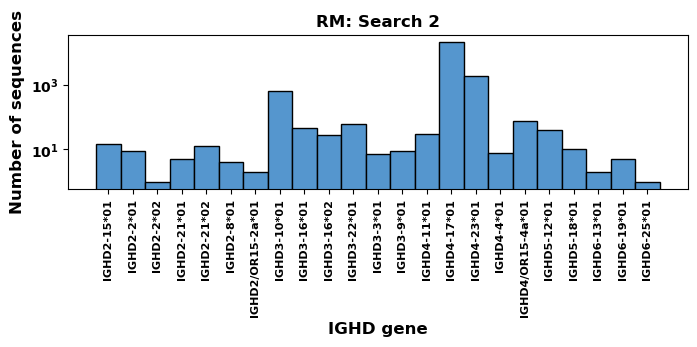

In [14]:
genes = np.concatenate(redundant_seqs_removed_within_donors_dgene_final)# np.load('updated_vgene.npy')
unique_genes = np.unique(genes)

barplot_genes = []
for i in range(len(unique_genes)):
    barplot_genes.append(list(genes).count(unique_genes[i]))

plt.figure(figsize=[8,2])
plt.bar(np.arange(len(barplot_genes)), barplot_genes, width=1, edgecolor='k', color='#5596ce')
plt.xticks(np.arange(len(barplot_genes)), unique_genes, rotation=90, fontsize=8)
plt.yscale('log')
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.ylabel('Number of sequences',weight='bold', fontsize=12)
plt.xlabel('IGHD gene',weight='bold', fontsize=12)
plt.title('RM: Search 2',weight='bold', fontsize=12)
figure_path = '/Users/ssolieva/Desktop/github_repo/q23-manuscript/repertoire-frequency-analysis/OAS-searches/figures/'
plt.savefig(f'{figure_path}RM_nonredundant_dgene_distribution.pdf', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

# D gene enrichment score plot

In [91]:
genes = np.concatenate(redundant_seqs_removed_within_donors_dgene_final) 
unique_genes = np.unique(genes)
print(unique_genes, len(unique_genes))

['IGHD2-15*01' 'IGHD2-2*01' 'IGHD2-2*02' 'IGHD2-21*01' 'IGHD2-21*02'
 'IGHD2-8*01' 'IGHD2/OR15-2a*01' 'IGHD3-10*01' 'IGHD3-16*01' 'IGHD3-16*02'
 'IGHD3-22*01' 'IGHD3-3*01' 'IGHD3-9*01' 'IGHD4-11*01' 'IGHD4-17*01'
 'IGHD4-23*01' 'IGHD4-4*01' 'IGHD4/OR15-4a*01' 'IGHD5-12*01' 'IGHD5-18*01'
 'IGHD6-13*01' 'IGHD6-19*01' 'IGHD6-25*01'] 23


In [96]:
OAS_data_path = '/Users/ssolieva/Desktop/Kulp_lab/projects/OAS_database_searches/gene_counts/IGHD/specific_genes/final_dgenes_counts_output.txt'
with open(OAS_data_path) as f:
    lines = [line.rstrip() for line in f]

total_dgene_counts = []
bar_plot_genenames = []
for line in lines:
    split_line = line.split(" ")
    #print(split_line[0], str(split_line[0][:-3]+'*'+split_line[0][-2:]))
    if str(split_line[0][:-3]+'*'+split_line[0][-2:]) in unique_genes:
        total_dgene_counts.append(int(split_line[1]))
        bar_plot_genenames.append(str(split_line[0][:-3]+'*'+split_line[0][-2:]))

hit_dgene_counts = []
for i in range(len(bar_plot_genenames)):
    hit_dgene_counts.append(list(genes).count(bar_plot_genenames[i]))

In [98]:
hit_dgene_counts/total_dgene_counts

TypeError: unsupported operand type(s) for /: 'list' and 'list'

In [110]:
old_numerator = np.load('/Users/ssolieva/Desktop/Kulp_lab/projects/OAS_database_searches/V033/updated_searches_05222024/search_03/EDDYG_search_dgenes_with_no_and_noname.npy')
print(old_numerator[0:10])

[1.06506481e-05 2.02362314e-04 1.38458425e-04 6.81641478e-04
 2.55615554e-04 4.26025924e-05 7.45545366e-05 2.34314258e-04
 6.07086941e-04 4.26025924e-05]


In [111]:
e = []
for i in range(len(hit_dgene_counts)):
    e.append((hit_dgene_counts[i]/24696)/ (total_dgene_counts[i]/1525390191))

In [112]:
np.log10(e)

array([-0.87244764, -1.08250619, -1.31928829, -0.80597534, -0.45919471,
       -0.84941618,  0.52622632, -0.16920484,  0.09413316, -0.53622417,
       -1.32676889, -0.76366591,  0.1534002 ,  2.3221886 ,  1.90885425,
       -0.20630096,  1.24097209, -0.21657377, -0.89121771, -1.87071101,
       -1.51846903, -1.09118354])

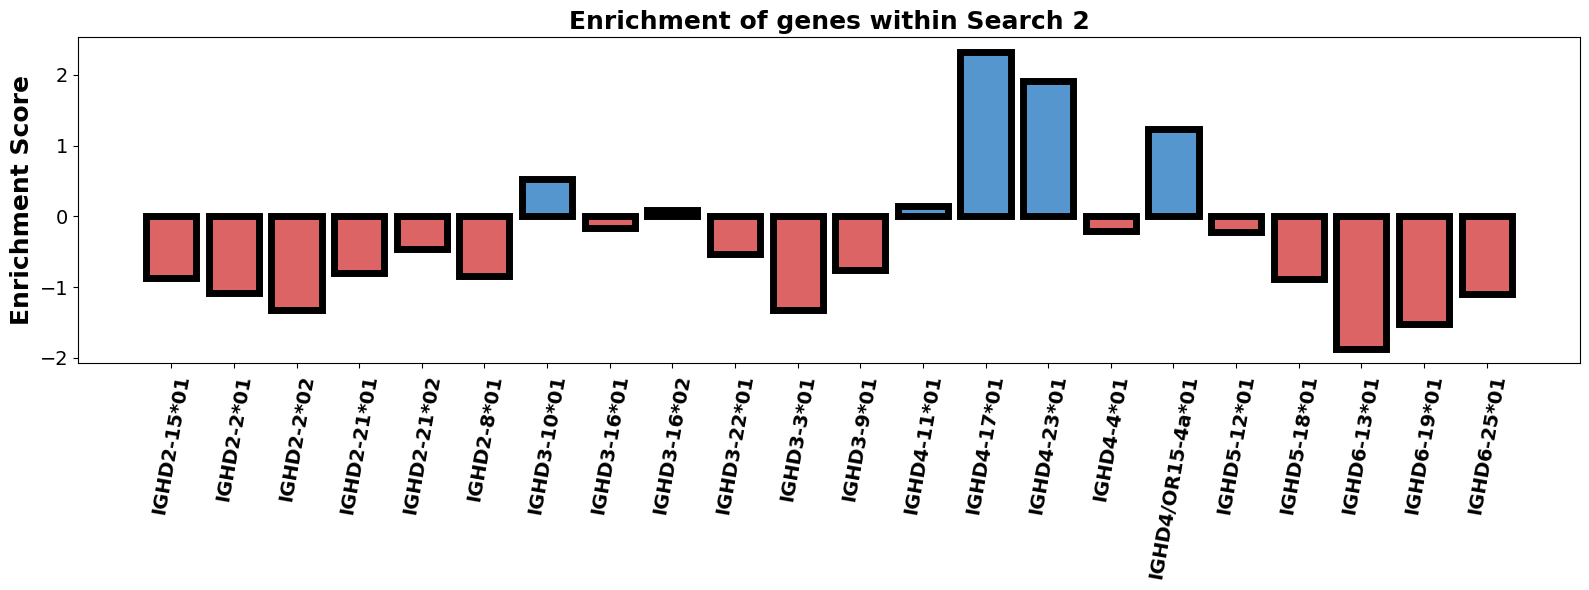

In [117]:
enrichment = np.log10(e)
positive_color='#5596ce'
negative_color='#dc6464'
colors = []
for i in range(len(enrichment)):
    if enrichment[i] <= 0:
        colors.append(negative_color)
    if enrichment[i] > 0:
        colors.append(positive_color)
        
plt.figure(figsize=[16,6])
plt.ylabel('Enrichment Score', fontsize=18, weight='bold')
plt.bar(bar_plot_xticks, np.log10(e), color=colors, edgecolor='k', linewidth=5)
plt.xticks(fontsize=14, rotation=80, weight='bold')
# plt.title("enrichment plot \nSearch 2: '^.{2,}EDDYG.{6,}$' all CDRH3 lengths \n including no and no name", fontsize=18, weight='bold')
plt.title('Enrichment of genes within Search 2', fontsize=18, weight='bold')
#plt.yscale('log')
plt.yticks(fontsize=14)
#plt.ylim(-5,5)
plt.tight_layout()
plt.savefig("log_enrichment_plot_2colors.pdf", dpi=300, transparent=True, )
figure_path = '/Users/ssolieva/Desktop/github_repo/q23-manuscript/repertoire-frequency-analysis/OAS-searches/figures/'
plt.savefig(f"{figure_path}Fig2_PanelB__RM_IGHDgene_enrichment_plot.png", dpi=300, transparent=True, bbox_inches='tight')
plt.savefig(f"{figure_path}Fig2_PanelB__RM_IGHDgene_enrichment_plot.pdf", dpi=300, transparent=True, bbox_inches='tight')

plt.show()